# Spatial Pathway Analysis

In [1]:
# %% Libraries

import os
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import pandas as pd
from scipy.sparse import issparse

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
COMB_V= 'cellcharter'
COMB_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{COMB_V}.h5ad'


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# %% Load the object
comb = sc.read_h5ad(COMB_PATH)

In [3]:
import numpy as np
import pandas as pd
import anndata as ad


def add_spatial_offset(
    adata: ad.AnnData,
    sample_key: str = "sample_name",
    spatial_key: str = "X_spatial",
    spatial_offset_key: str = "X_spatial_offset",
    gap_mult: float = 2.0,
    inplace: bool = True,
) -> ad.AnnData | None:
    """
    Offset x coordinates by sample so each sample is plotted apart horizontally.

    Parameters
    ----------
    adata : AnnData
        AnnData object containing spatial coordinates in `obsm[spatial_key]`
        and sample metadata in `obs[sample_key]`.
    sample_key : str
        Column in `adata.obs` identifying the sample for each cell.
    spatial_key : str
        Key in `adata.obsm` containing the original spatial coordinates.
        Expected shape: (n_cells, 2) with columns [x, y].
    spatial_offset_key : str
        Key in `adata.obsm` where offset coordinates will be saved.
    gap_mult : float
        Multiplier controlling spacing between samples along the x axis.
    inplace : bool
        If True, modify `adata` in place and return None.
        If False, return a modified copy.

    Returns
    -------
    AnnData | None
        Modified AnnData if `inplace=False`, else None.
    """
    if spatial_key not in adata.obsm:
        raise ValueError(f"{spatial_key!r} not found in adata.obsm")

    if sample_key not in adata.obs.columns:
        raise ValueError(f"{sample_key!r} not found in adata.obs")

    spatial = np.asarray(adata.obsm[spatial_key])

    if spatial.ndim != 2 or spatial.shape[1] < 2:
        raise ValueError(
            f"adata.obsm[{spatial_key!r}] must have shape (n_cells, 2+) "
            f"but got {spatial.shape}"
        )

    obj = adata if inplace else adata.copy()

    x0 = spatial[:, 0].astype(np.float32)
    y0 = spatial[:, 1].astype(np.float32)

    samples = obj.obs[sample_key].astype(str)
    sample_order = pd.unique(samples)
    sample_to_idx = {sample: i for i, sample in enumerate(sample_order)}
    idx = samples.map(sample_to_idx).to_numpy(dtype=np.float32)

    if np.isnan(idx).any():
        bad = samples[pd.isna(samples.map(sample_to_idx))].unique()
        raise ValueError(f"Unmapped sample(s) detected: {bad}")

    x_range = float(x0.max() - x0.min())
    gap = x_range * gap_mult

    spatial_offset = np.column_stack([
        x0 + idx * gap,
        y0,
    ]).astype(np.float32)

    obj.obsm[spatial_offset_key] = spatial_offset

    if not inplace:
        return obj

# NOTE: the output of this funciton should be saved in obsm

In [4]:
# transform pixels to um
comb.obsm["spatial"] = comb.obsm["X_spatial"] * 0.12028

In [5]:
add_spatial_offset(
    comb,
    sample_key="sample_name",
    spatial_key="spatial",
    spatial_offset_key="spatial",
    gap_mult=2.0,
    inplace=True,
)

comb

AnnData object with n_obs × n_vars = 1187341 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_

In [6]:
import decoupler as dc
dc.pp.knn(comb, key="spatial", bw=1, cutoff=0.1)

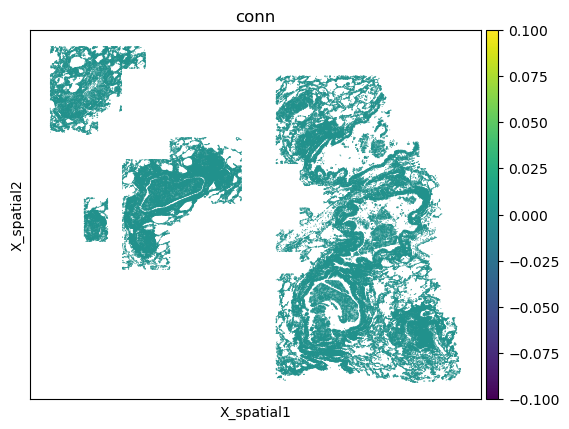

In [11]:
# Plot the spatial weights of one spot
comb.obs["conn"] = comb.obsp["spatial_connectivities"][0].toarray().ravel()
sc.pl.embedding(
    comb[comb.obs['sample_name']== 'PWCF01_1'],
    basis="X_spatial", 
    color="conn", 
    size=1.5,
    vmin='p90'
)

In [7]:
sc.pp.normalize_total(comb, target_sum=1e4, layer='counts')
sc.pp.log1p(comb)
comb.layers["norm"] = comb.X.copy()

In [8]:
# Update X with spatially weighted gene exression
comb.X = comb.obsp["spatial_connectivities"].dot(comb.X)

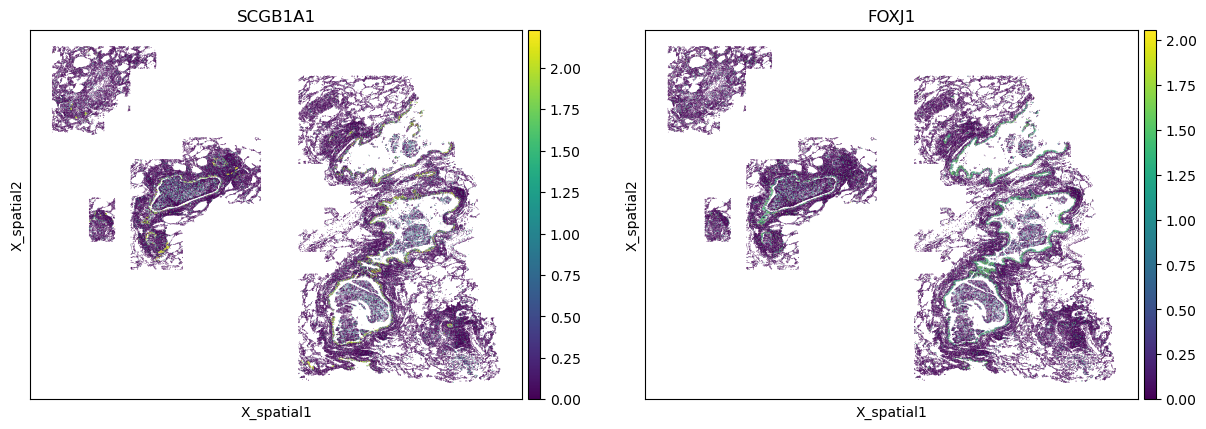

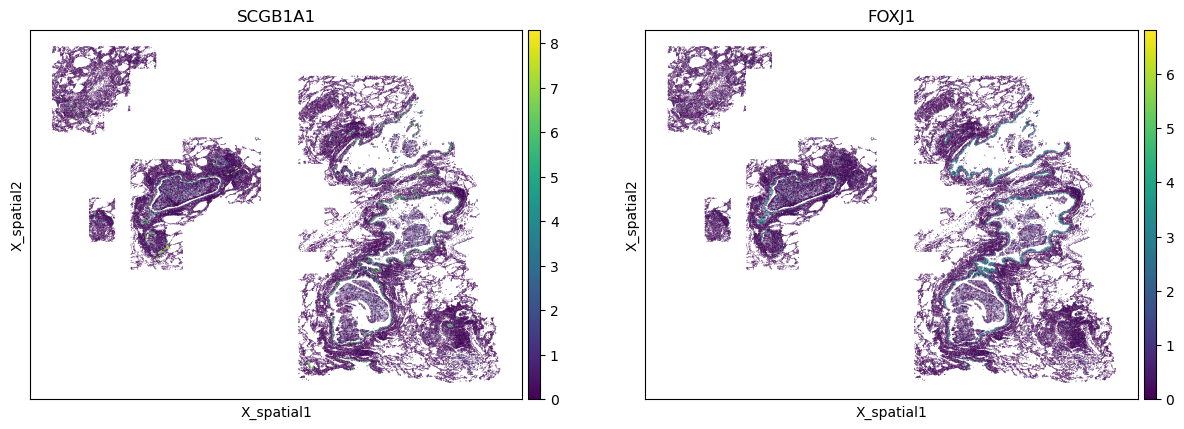

In [9]:
genes = ["SCGB1A1", "FOXJ1"]

sc.pl.embedding(
    adata=comb[comb.obs['sample_name']== 'PWCF01_1'], 
    color=genes, 
    basis="X_spatial", 
    palette="viridis",
    layer='norm'
)

sc.pl.embedding(
    adata=comb[comb.obs['sample_name']== 'PWCF01_1'], 
    color=genes, 
    basis="X_spatial", 
    palette="viridis"
)

## CollecTRI

In [10]:
collectri = dc.op.collectri(organism="human")
collectri

,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
...,...,...,...,...,...,...
42985,NFKB,hsa-miR-143-3p,1.0,ExTRI,19472311,default activation
42986,AP1,hsa-miR-206,1.0,ExTRI;GEREDB;NTNU.Curated,19721712,PMID
42987,NFKB,hsa-miR-21,1.0,ExTRI,20813833;22387281,default activation
42988,NFKB,hsa-miR-224-5p,1.0,ExTRI,23474441;23988648,default activation


In [11]:
dc.mt.ulm(data=comb, net=collectri)

In [12]:
score = dc.pp.get_obsm(adata=comb, key="score_ulm")
score

AnnData object with n_obs × n_vars = 1187341 × 514
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_6

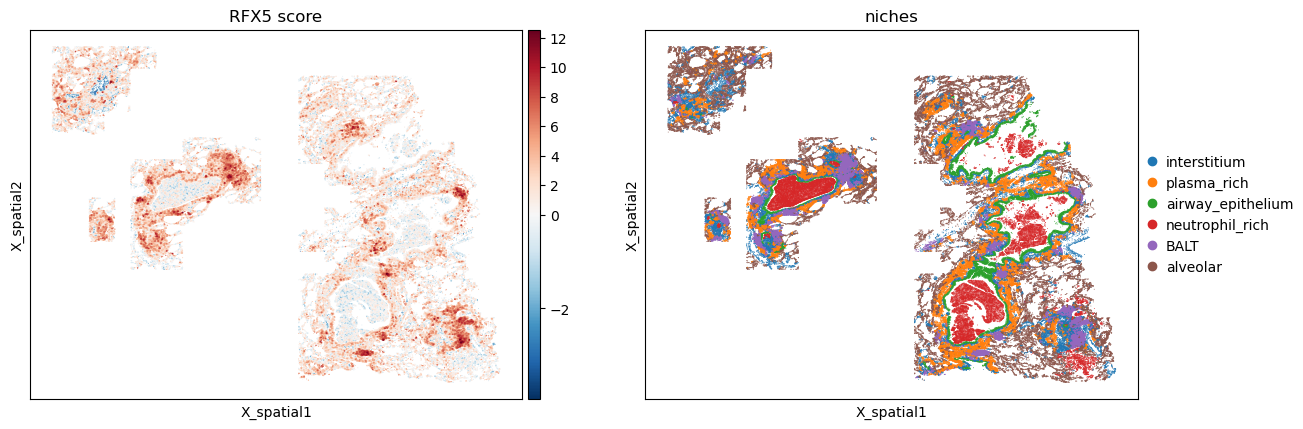

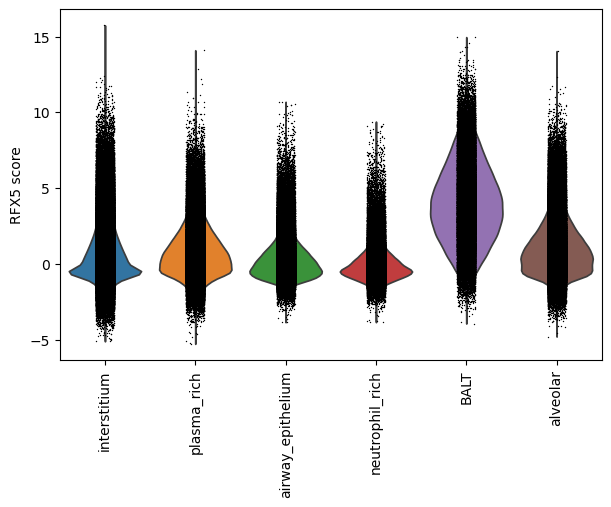

In [13]:
tf = "RFX5"
sc.pl.embedding(score[score.obs['sample_name']== 'PWCF01_1'], basis='X_spatial', color=[tf, "niche_name"], cmap="RdBu_r", vcenter=0, size=1.5, title=[f"{tf} score", "niches"])
sc.pl.violin(score, keys=tf, groupby="niche_name", rotation=90, ylabel=f"{tf} score")

In [14]:
df = dc.tl.rankby_group(adata=score, groupby="niche_name", reference="rest", method="t-test_overestim_var")
df = df[df["stat"] > 0.0]
df

,group,reference,name,stat,meanchange,pval,padj
0,interstitium,rest,SMAD3,244.052972,1.087421,0.000000,0.000000
1,interstitium,rest,GATA4,227.740934,0.637827,0.000000,0.000000
2,interstitium,rest,SRF,212.469045,0.956858,0.000000,0.000000
3,interstitium,rest,HHEX,211.898682,0.683646,0.000000,0.000000
4,interstitium,rest,NFIC,203.830310,0.657914,0.000000,0.000000
...,...,...,...,...,...,...,...
3072,neutrophil_rich,rest,FOXA2,3.401652,0.013737,0.000670,0.000685
3073,neutrophil_rich,rest,TP73,3.288510,0.014902,0.001007,0.001027
3075,neutrophil_rich,rest,ATF1,2.333752,0.010433,0.019610,0.019920
3076,neutrophil_rich,rest,RARB,1.814188,0.006491,0.069650,0.070612


In [15]:
n_markers = 3
source_markers = (
    df.groupby("group")
    .head(n_markers)
    .drop_duplicates("name")
    .groupby("group")["name"]
    .apply(lambda x: list(x))
    .to_dict()
)
source_markers

/tmp/ipykernel_1360231/1918982502.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("group")
/tmp/ipykernel_1360231/1918982502.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group")["name"]


{'BALT': ['BCL6', 'RFXAP', 'RFXANK'],
 'airway_epithelium': ['FOXJ1', 'TP63', 'SOX2'],
 'alveolar': ['FOXA1', 'THRB', 'TTF1'],
 'interstitium': ['SMAD3', 'GATA4', 'SRF'],
 'neutrophil_rich': ['MYT1', 'APEX1', 'LHX2'],
 'plasma_rich': ['GSC', 'TBXT', 'PAX5']}

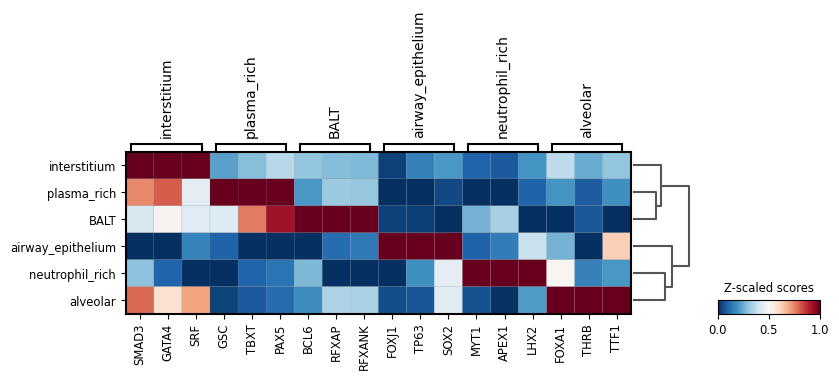

In [16]:
sc.pl.matrixplot(
    adata=score,
    var_names=source_markers,
    groupby="niche_name",
    dendrogram=True,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
)

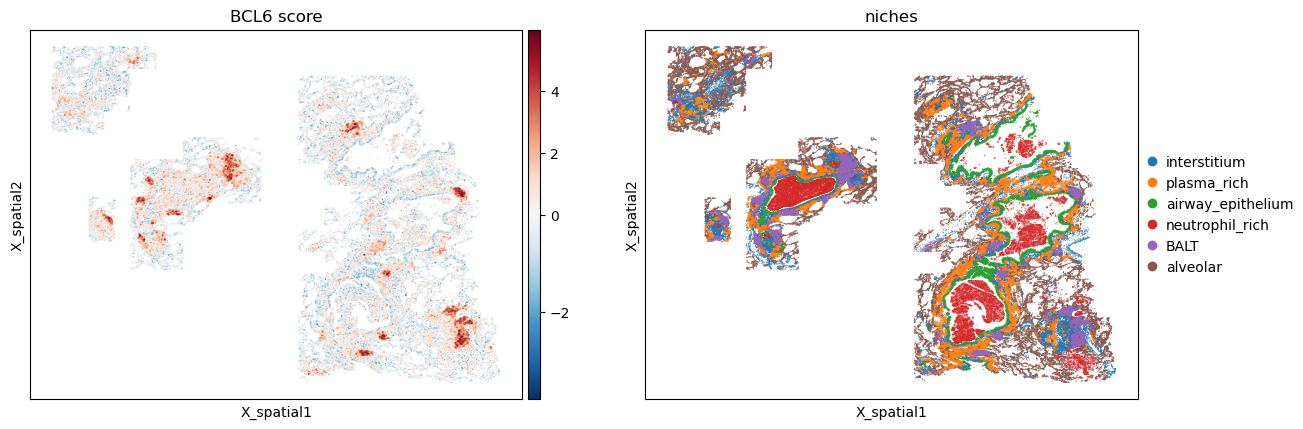

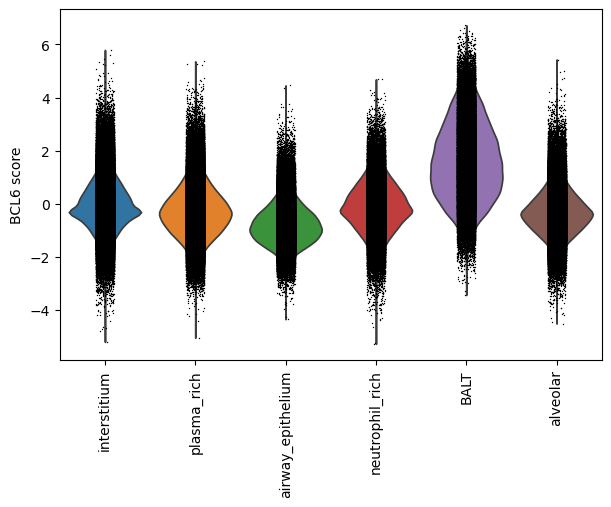

In [17]:
tf = "BCL6" # test a good one 
sc.pl.embedding(score[score.obs['sample_name']== 'PWCF01_1'],basis='X_spatial', color=[tf, "niche_name"], cmap="RdBu_r", vcenter=0, size=1.5, title=[f"{tf} score", "niches"])
sc.pl.violin(score, keys=[tf], groupby="niche_name", rotation=90, ylabel=f"{tf} score")

## PROGENy

In [18]:
progeny = dc.op.progeny(organism="human")
progeny

,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40
...,...,...,...,...
62416,p53,ENPP2,2.771405,4.993215e-02
62417,p53,ARRDC4,3.494328,4.996747e-02
62418,p53,MYO1B,-1.148057,4.997905e-02
62419,p53,CTSC,-1.784693,4.998864e-02


In [19]:
dc.mt.ulm(data=comb, net=progeny)

In [20]:
score = dc.pp.get_obsm(adata=comb, key="score_ulm")
score

AnnData object with n_obs × n_vars = 1187341 × 14
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_6'

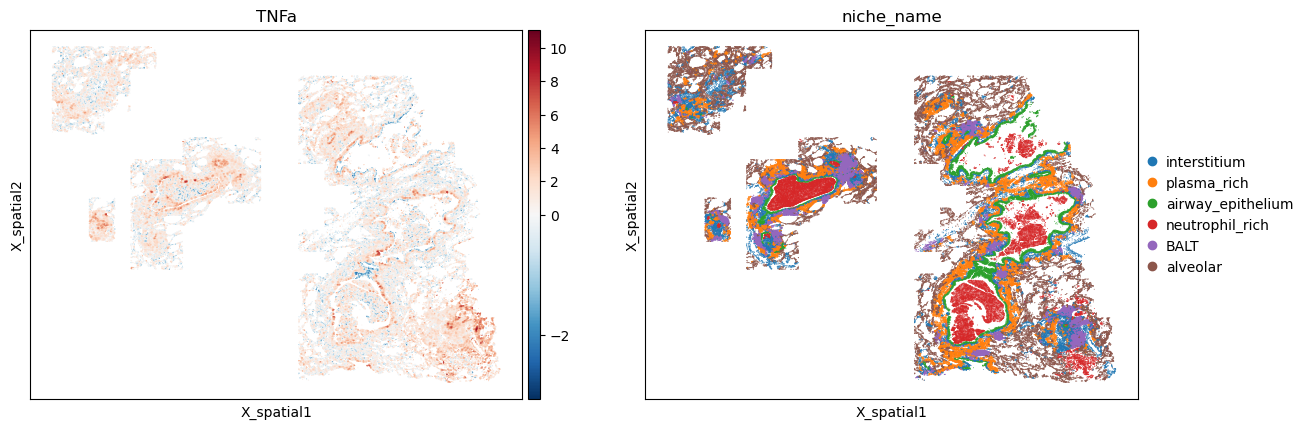

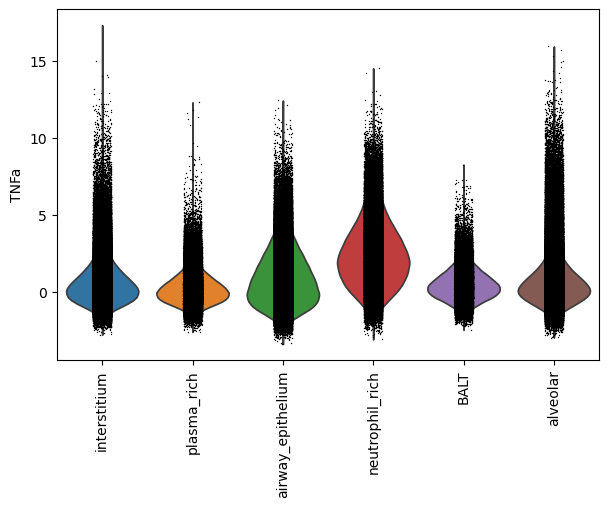

In [21]:
pw = "TNFa"
sc.pl.embedding(score[score.obs['sample_name']== 'PWCF01_1'],basis='X_spatial', color=[pw, "niche_name"], cmap="RdBu_r", vcenter=0, size=1.5)
sc.pl.violin(score, keys=[pw], groupby="niche_name", rotation=90)

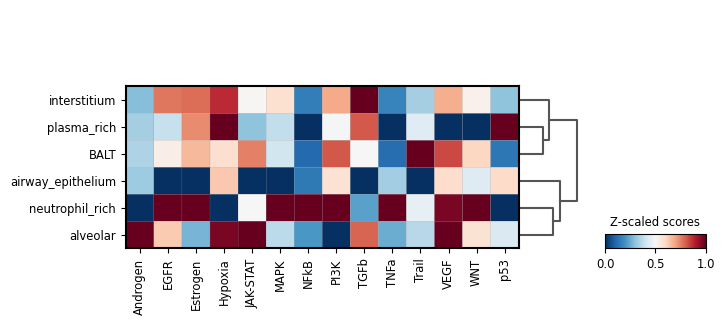

In [22]:
sc.pl.matrixplot(
    adata=score,
    var_names=score.var_names,
    groupby="niche_name",
    dendrogram=True,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
)

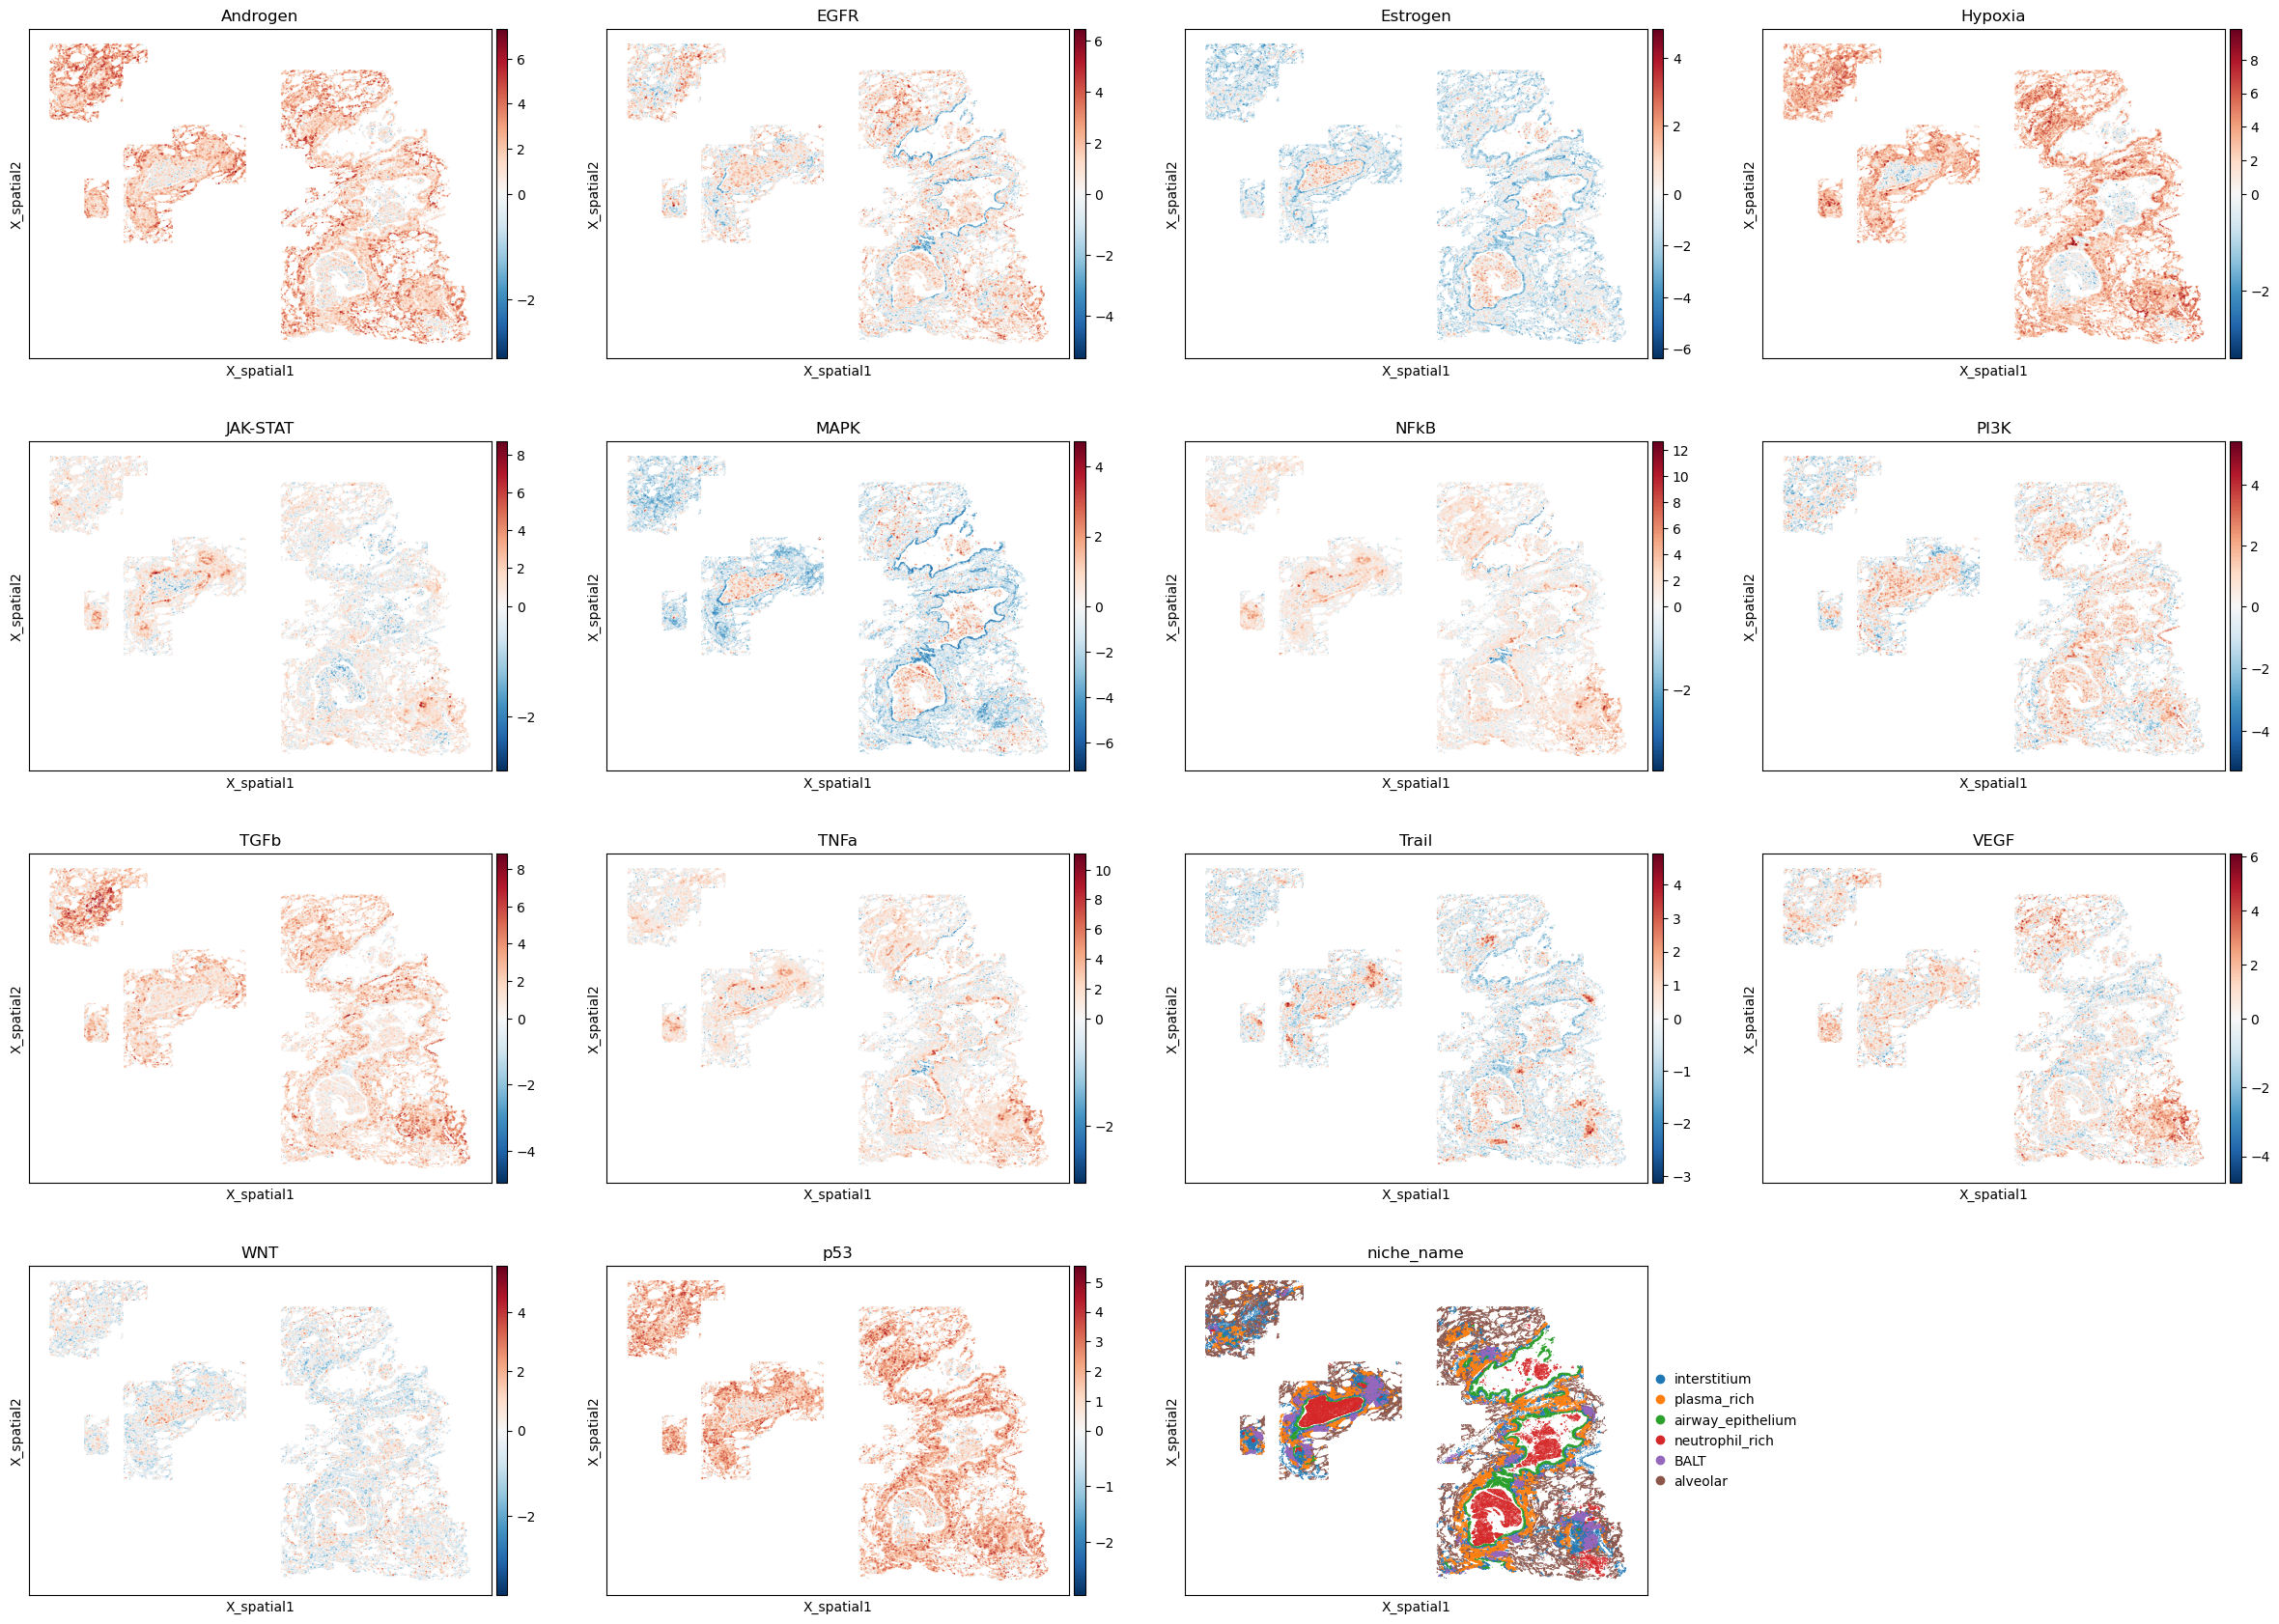

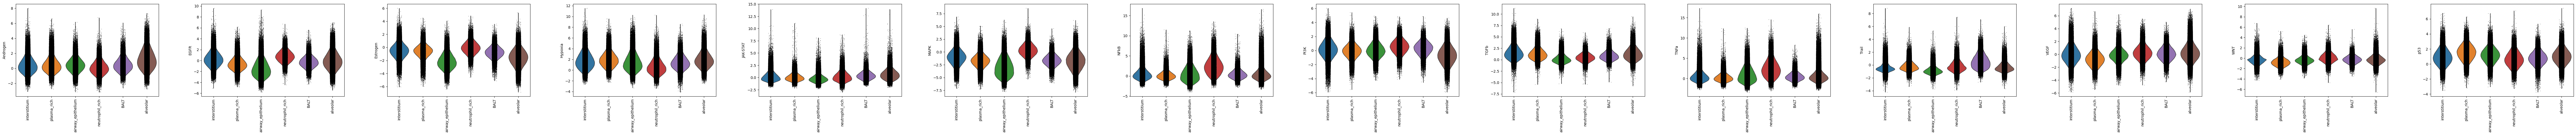

In [23]:
pws = progeny['source'].unique().tolist()
sc.pl.embedding(score[score.obs['sample_name']== 'PWCF01_1'], basis='X_spatial', color=pws + ["niche_name"], cmap="RdBu_r", vcenter=0, size=1.5)
sc.pl.violin(score, keys=pws, groupby="niche_name", rotation=90)

## Hallmark

In [24]:
hallmark = dc.op.hallmark(organism="human")
hallmark

,source,target
0,IL2_STAT5_SIGNALING,MAFF
1,COAGULATION,MAFF
2,HYPOXIA,MAFF
3,TNFA_SIGNALING_VIA_NFKB,MAFF
4,COMPLEMENT,MAFF
...,...,...
7313,PANCREAS_BETA_CELLS,STXBP1
7314,PANCREAS_BETA_CELLS,ELP4
7315,PANCREAS_BETA_CELLS,GCG
7316,PANCREAS_BETA_CELLS,PCSK2


In [25]:
dc.mt.ulm(data=comb, net=hallmark)

In [26]:
score = dc.pp.get_obsm(adata=comb, key="score_ulm")
score

AnnData object with n_obs × n_vars = 1187341 × 50
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_6'

In [27]:
df = dc.tl.rankby_group(adata=score, groupby="niche_name", reference="rest", method="t-test_overestim_var")
df = df[df["stat"] > 0]
df

,group,reference,name,stat,meanchange,pval,padj
0,interstitium,rest,EPITHELIAL_MESENCHYMAL_TRANSITION,275.044862,1.899291,0.000000e+00,0.000000e+00
1,interstitium,rest,MYOGENESIS,258.191050,1.032422,0.000000e+00,0.000000e+00
2,interstitium,rest,ANGIOGENESIS,201.607445,0.748953,0.000000e+00,0.000000e+00
3,interstitium,rest,COAGULATION,125.873250,0.559103,0.000000e+00,0.000000e+00
4,interstitium,rest,PANCREAS_BETA_CELLS,116.960079,0.213929,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...
292,neutrophil_rich,rest,MYC_TARGETS_V2,31.894853,0.117147,1.078861e-222,1.254490e-222
293,neutrophil_rich,rest,FATTY_ACID_METABOLISM,30.527496,0.142446,3.176311e-204,3.609444e-204
294,neutrophil_rich,rest,SPERMATOGENESIS,29.085403,0.111422,1.275636e-185,1.417374e-185
297,neutrophil_rich,rest,WNT_BETA_CATENIN_SIGNALING,15.654557,0.056974,3.321232e-55,3.459616e-55


In [28]:
n_markers = 3
source_markers = (
    df.groupby("group")
    .head(n_markers)
    .drop_duplicates("name")
    .groupby("group")["name"]
    .apply(lambda x: list(x))
    .to_dict()
)
source_markers

/tmp/ipykernel_1360231/1918982502.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("group")
/tmp/ipykernel_1360231/1918982502.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group")["name"]


{'BALT': ['ALLOGRAFT_REJECTION', 'KRAS_SIGNALING_UP'],
 'airway_epithelium': ['ESTROGEN_RESPONSE_EARLY',
  'PEROXISOME',
  'ESTROGEN_RESPONSE_LATE'],
 'alveolar': ['COAGULATION', 'ADIPOGENESIS', 'CHOLESTEROL_HOMEOSTASIS'],
 'interstitium': ['EPITHELIAL_MESENCHYMAL_TRANSITION',
  'MYOGENESIS',
  'ANGIOGENESIS'],
 'neutrophil_rich': ['INFLAMMATORY_RESPONSE', 'PANCREAS_BETA_CELLS'],
 'plasma_rich': ['UNFOLDED_PROTEIN_RESPONSE',
  'MTORC1_SIGNALING',
  'PI3K_AKT_MTOR_SIGNALING']}

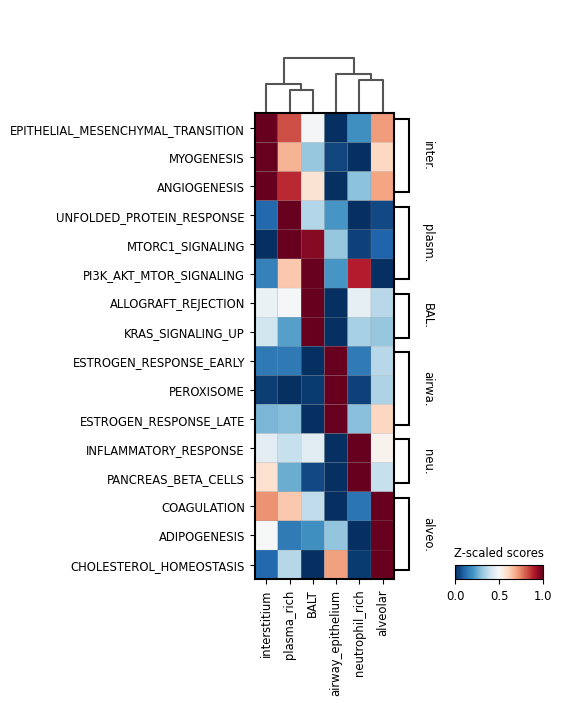

In [29]:
sc.pl.matrixplot(
    adata=score,
    var_names=source_markers,
    groupby="niche_name",
    dendrogram=True,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
    swap_axes=True,
)

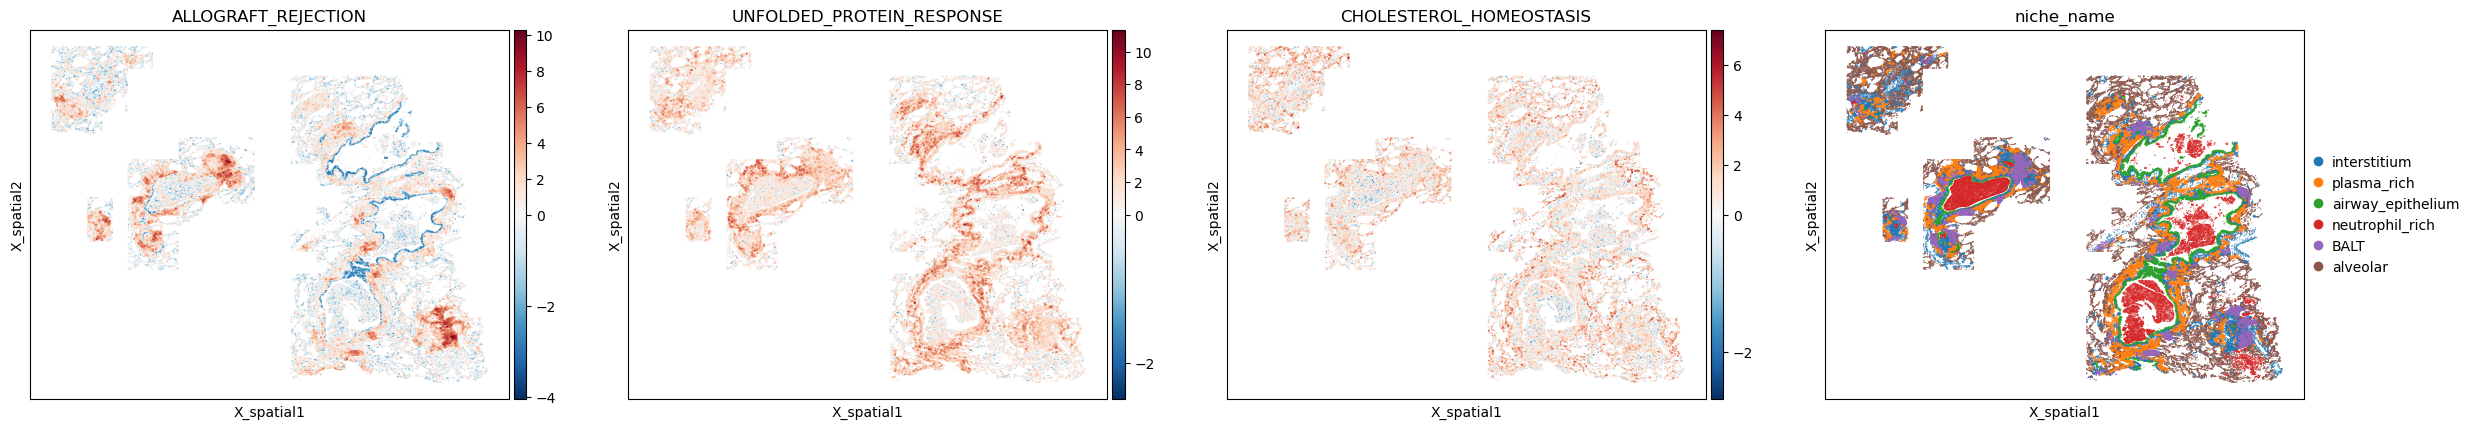

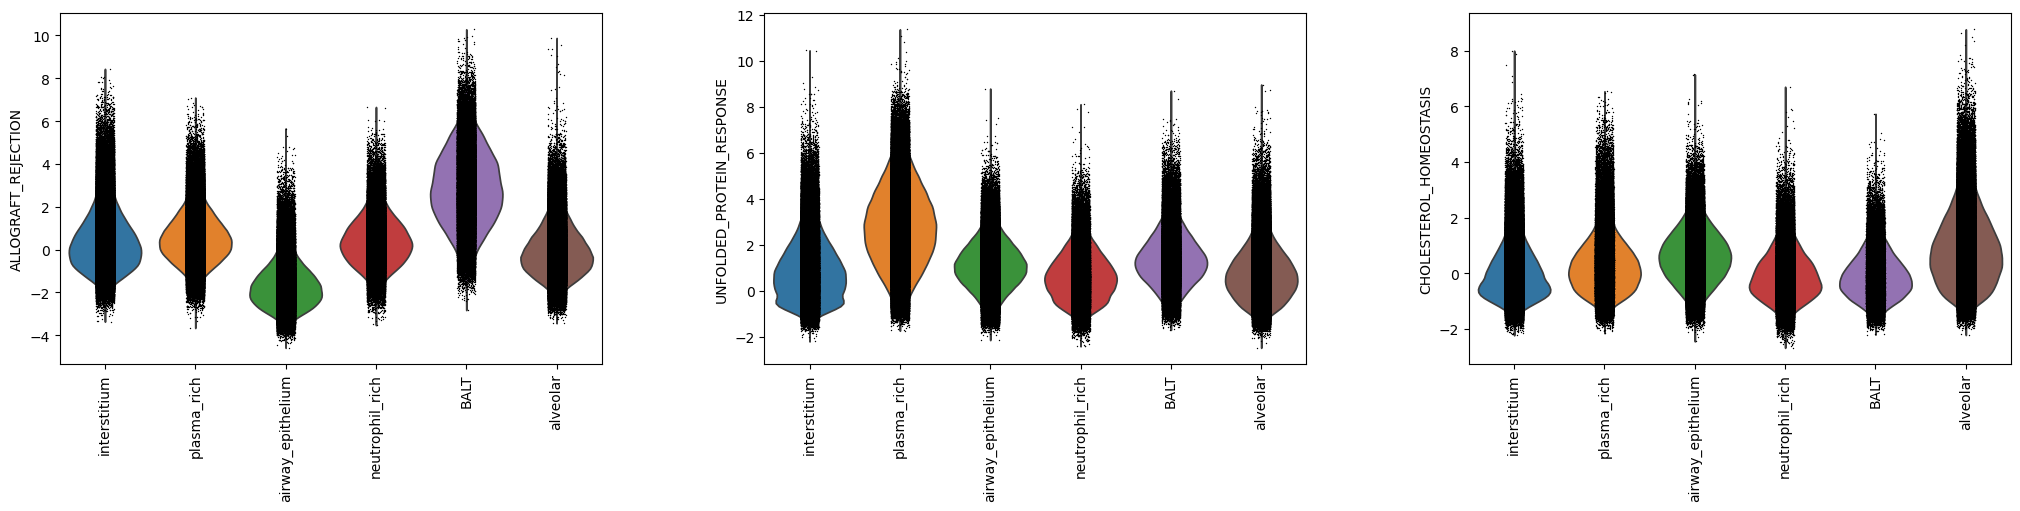

In [32]:
hms = ["ALLOGRAFT_REJECTION", "UNFOLDED_PROTEIN_RESPONSE", "CHOLESTEROL_HOMEOSTASIS"]
sc.pl.embedding(score[score.obs['sample_name']== 'PWCF01_1'], basis='X_spatial', color=hms + ["niche_name"], cmap="RdBu_r", vcenter=0, size=1.5)
sc.pl.violin(score, keys=hms, groupby="niche_name", rotation=90)